# 02 – Data Preprocessing & Feature Engineering
**House Prices – Advanced Regression Techniques | Central AI Assessment**

---

This notebook covers:
- Missing value imputation strategy
- Ordinal encoding of quality/condition features
- Domain-driven feature engineering
- Skewness correction (Box-Cox)
- One-hot encoding
- Preprocessed dataset validation

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

sys.path.append(str(Path('..').resolve()))
from src.data_preprocessing import preprocess, QUAL_MAP
from src.feature_engineering import add_features

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../outputs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')
print(f'Train: {train.shape}  |  Test: {test.shape}')

Train: (1460, 81)  |  Test: (1459, 80)


## 1. Imputation Strategy

| Category | Columns | Strategy | Rationale |
|----------|---------|----------|-----------|
| Structural absence | PoolQC, Alley, Fence, FireplaceQu, Garage*, Bsmt*, MasVnrType | `'None'` string | NA = no such feature exists |
| Area / count | GarageArea, GarageCars, Bsmt*SF, Bsmt*Bath, MasVnrArea | `0` | No feature = zero area |
| LotFrontage | LotFrontage | Neighbourhood median | Frontage correlates with local street layout |
| Low-NA categoricals | MSZoning, Electrical, KitchenQual, Exterior1st, Exterior2nd, SaleType | Mode | Minimal information loss |
| Functional | Functional | `'Typ'` | Most common value; NA implies typical |
| GarageYrBlt | GarageYrBlt | `YearBuilt` | Garage built same year as house if unknown |

## 2. Feature Engineering

Engineered features created before encoding:

| Feature | Formula |
|---------|--------|
| `TotalSF` | `TotalBsmtSF + 1stFlrSF + 2ndFlrSF` |
| `TotalBaths` | `FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath` |
| `TotalPorchSF` | Sum of all porch areas |
| `HouseAge` | `YrSold - YearBuilt` |
| `RemodAge` | `YrSold - YearRemodAdd` |
| `IsRemodeled` | Binary: house was remodelled |
| `IsNew` | Binary: sold same year as built |
| `OverallScore` | `OverallQual × OverallCond` |
| `QualSF` | `OverallQual × TotalSF` |
| `QualGrLiv` | `OverallQual × GrLivArea` |
| `GarageScore` | `GarageCars × GarageQual` |
| `Has*` | Binary indicators for pool, 2nd floor, garage, basement, fireplace |

## 3. Run Full Preprocessing Pipeline

In [2]:
X, y, X_test = preprocess(train, test)

print(f'Training set shape : {X.shape}')
print(f'Test set shape     : {X_test.shape}')
print(f'Remaining NaN (train): {X.isnull().sum().sum()}')
print(f'Remaining NaN (test) : {X_test.isnull().sum().sum()}')

Training set shape : (1458, 203)
Test set shape     : (1459, 203)
Remaining NaN (train): 0
Remaining NaN (test) : 0


## 4. Skewness Before vs After

Features with |skew| > 0.75 before preprocessing: 21
Features with |skew| > 0.75 after  preprocessing: 21


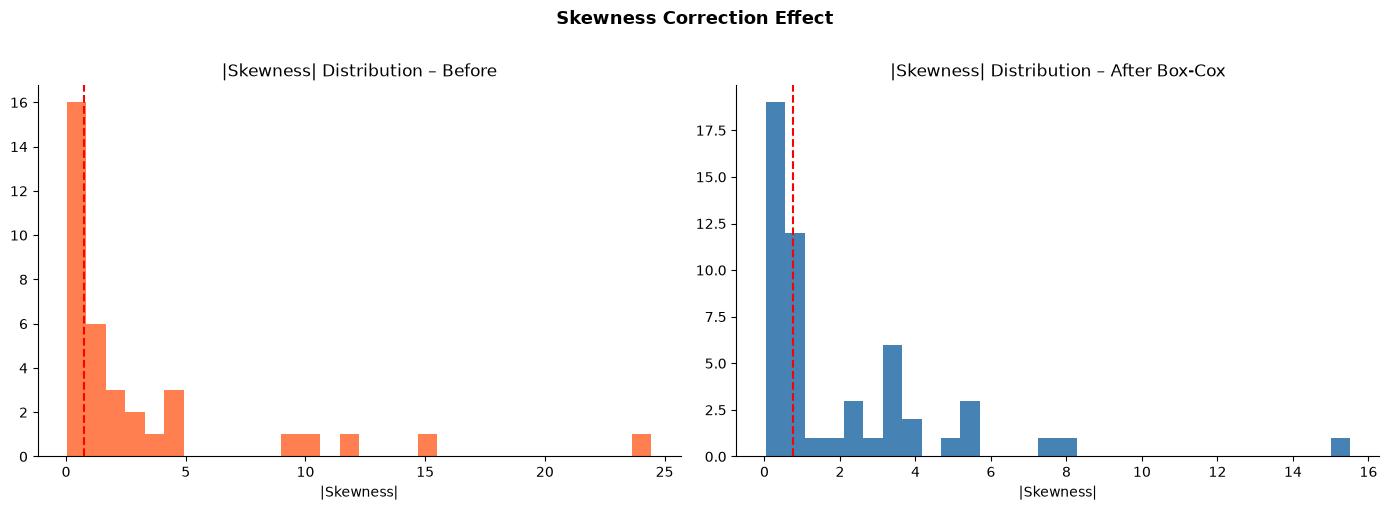

In [3]:
# Skewness of raw numerical features before preprocessing
raw_num  = train.select_dtypes(include=[np.number]).drop(columns=['Id', 'SalePrice'])
raw_skew = raw_num.apply(lambda s: abs(skew(s.dropna())))
high_skew_before = (raw_skew > 0.75).sum()

# Skewness after preprocessing
proc_num   = X.select_dtypes(include=[np.number])
proc_skew  = proc_num.apply(lambda s: abs(skew(s.dropna())))
high_skew_after = (proc_skew > 0.75).sum()

print(f'Features with |skew| > 0.75 before preprocessing: {high_skew_before}')
print(f'Features with |skew| > 0.75 after  preprocessing: {high_skew_after}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(raw_skew, bins=30, color='coral')
axes[0].axvline(0.75, color='red', linestyle='--')
axes[0].set_title('|Skewness| Distribution – Before')
axes[0].set_xlabel('|Skewness|')

axes[1].hist(proc_skew, bins=30, color='steelblue')
axes[1].axvline(0.75, color='red', linestyle='--')
axes[1].set_title('|Skewness| Distribution – After Box-Cox')
axes[1].set_xlabel('|Skewness|')

plt.suptitle('Skewness Correction Effect', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'skewness_correction.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Count Summary

In [4]:
print(f'Raw features          : {train.shape[1] - 2}  (excl. Id, SalePrice)')
print(f'After engineering     : {X.shape[1]}')
print(f'\nTarget (y) range      : [{y.min():.4f}, {y.max():.4f}]')
print(f'Target (y) mean       : {y.mean():.4f}')

Raw features          : 79  (excl. Id, SalePrice)
After engineering     : 203

Target (y) range      : [10.4603, 13.5345]
Target (y) mean       : 12.0240


## 6. Save Processed Features

Save to `outputs/` for use in downstream notebooks.

In [5]:
import pickle
from pathlib import Path

OUT = Path('../outputs')
OUT.mkdir(exist_ok=True)

X.to_parquet(OUT / 'X_train.parquet', index=False)
X_test.to_parquet(OUT / 'X_test.parquet', index=False)
np.save(OUT / 'y_train.npy', y)

print('Saved:')
print(f'  {OUT}/X_train.parquet   shape={X.shape}')
print(f'  {OUT}/X_test.parquet    shape={X_test.shape}')
print(f'  {OUT}/y_train.npy       shape={y.shape}')

Saved:
  ..\outputs/X_train.parquet   shape=(1458, 203)
  ..\outputs/X_test.parquet    shape=(1459, 203)
  ..\outputs/y_train.npy       shape=(1458,)
